<a href="https://colab.research.google.com/github/Mehttap/Machine_Learning/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Support Vector Machines - Destek Vektör Makineleri (SVM)**

SVM, hem sınıflandırma hem de regresyon problemlerinde kullanılan güçlü bit makine öğrenmesi yöntemidir. Temel amaç, farklı sınıflara ait verileri en iyi ayıran hiper-düzlemi(hyperplane) bulmaktır.

SVM algoritması bu hiper-düzlemi seçerken marjin adı verilen iki sınıf arasındaki mesafeyi maksimum yapmaya çalışır. Bu yaklaşım sayesinde model genellikle iyi genelleme performansı gösterir.

In [7]:
#Modülleri Yükleyelim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [2]:
#Veri Setinin Yüklenmesi

data = load_breast_cancer()

X = data.data
y = data.target

print("Özellik Sayısı:", X.shape[1])
print("Örnek Sayısı:",  X.shape[0])


Özellik Sayısı: 30
Örnek Sayısı: 569


In [3]:
#Data Frame Oluşturma

df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


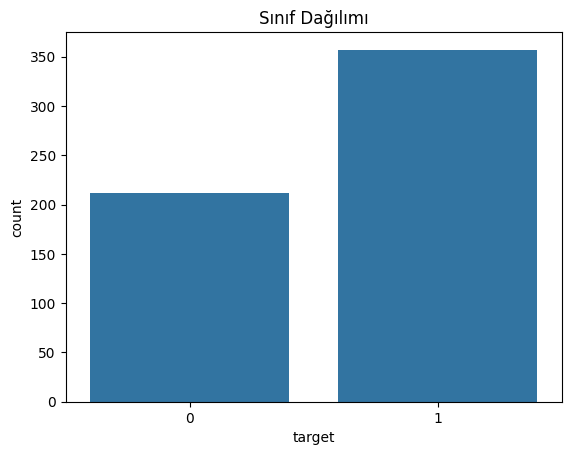

In [4]:
#Sınıf Dağılımının Görselleştirilmesi

sns.countplot(x="target", data=df)
plt.title("Sınıf Dağılımı")
plt.show()


Yukarıdaki Dagılımda;

0--> malignant (kötü huylu)
1--> benign (iyi huylu)

Yukarıdaki grafik ile verisetinin dengesini görmüş olduk.

Şimdi eğitim ve test için kullanacağımız şekilde veri setimizi böleceğiz:

In [5]:
#Veri setinin Train-Test olarak bölünmesi

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train veri boyutu:", X_train.shape)
print("Test veri boyutu:",  X_test.shape)

Train veri boyutu: (455, 30)
Test veri boyutu: (114, 30)


Yukarıda test_size=0.2 ile %80 eğitim için %20 test için verisetimizi böldük.

Şimdi FEATURE SCALING(Ölçeklendirme) kullanıcağız. Çünkü SVM algoritmaları ölçek farklarına duyarlıdır, bu nedenle veri ölçeklendirilmelidir.

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**SVM MODELINI OLUŞTURALIM**

İlk olarak linear kernel kullanalım.

In [10]:
#Linear Kernel Kullanalım
svm_model = SVC(kernel='linear')
svm_model.fit (X_train_scaled, y_train)

SVC(kernel='linear')

Modelimizi eğittik şimdi tahmin yapıracağız, ilk olarak ilk 10 veriye bakalım.

In [11]:
#Tahmin Yapma

y_pred = svm_model.predict(X_test_scaled)

print(y_pred[:10])

[1 0 0 1 1 0 0 0 0 1]


Yukarıda ilk 10 verimiz ile ilgili eğitmiş olduğumuz modelimize tahmin yaptırdık. Daha sonra bu çıktının doğru olup olmadığını Test datamız üzerinden kontrol edeceğiz.



In [12]:
#MODEL PERFORMANSININ DEĞERLENDİRİLMESİ

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.956140350877193


Yukarıda doğruluk skorunu veren "accuracy" fonksiyonu ile test datamız ile (modelin eğitiminde kullanmadığımız kısım yani gerçek değerlerimiz "y_test") ve modelimizin bize verdiği tahmini ("y_pred") karşılaştırıyoruz.

Sonuç olarak %95 doğruluk verdi.

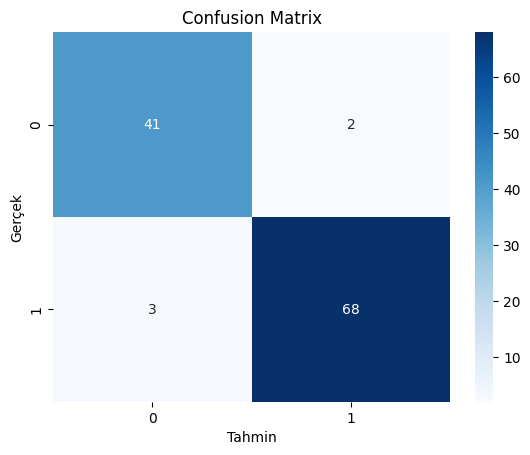

In [13]:
#KARMAŞIKLIK MATRISI

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix")
plt.show()

In [14]:
#SINIFLANDIRMA RAPORU

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



**KERNEL TRICK**


Kernel (çekirdek fonksiyonu), veriyi daha yüksek boyutlu bir uzaya taşıyarak daha kolay ayrılmasını sağlayan matematiksel bir “hile”dir.

2 boyutlu veriler düz bir çizgiyle ayrılamıyorsa, Kernel sayesinde veriyi 3 boyuta çıkarırız ve artık düz bir düzlemle ayırabiliriz. Yani,verimizi gerçekten dönüştürmeden, sanki dönüştürmüşüz gibi hesap yapar.



**RBF Kernel (Radial Basis Function)**

RBF Kernel ile verinin merkezlere olan uzaklığına göre benzerlik hesaplarız.

- Yakın noktalar → çok benzer
- Uzak noktalar → benzer değil

Şimdi farklı KERNEL Fonksiyonlarının Karşılaştırılmasını yapalım.


In [16]:
#RBF Kernel

svm_rbf = SVC(kernel='rbf')

svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)

print("RBF Doğruluğu:", accuracy_score(y_test, y_pred_rbf))

RBF Doğruluğu: 0.9824561403508771


RBF Kernel kullandığımızda doğruluk oranı %98'e çıktı.

**Polynomial Kernel**

Polynomial Kernel ise verimizi polinom şeklinde genişletir.

In [18]:
#Polynomial Kernel

svm_poly = SVC(kernel='poly', degree=3)

svm_poly.fit(X_train_scaled, y_train)

y_pred_poly = svm_poly.predict(X_test_scaled)

print("Polynomial Doğruluğu:", accuracy_score(y_test, y_pred_poly))

Polynomial Doğruluğu: 0.868421052631579


In [21]:
#Sonuçların Karşılaştırılması

results = pd.DataFrame({
    "Model" : ["Linear SVM", "RBF SVM", "Polynomial SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rbf),
        accuracy_score(y_test, y_pred_poly)
    ]
})

results

,Model,Accuracy
0,Linear SVM,0.956140
1,RBF SVM,0.982456
2,Polynomial SVM,0.868421


RBF'nın kullanıldıgı bir SVM yi uygulayabiliriz.